# 1. INSTALL DEPENDENCIES

In [2]:
# ============================================================
# Purpose: install the data + Unsloth training stack (Colab T4), pinned for compatibility.
# CHANGED: installs run via subprocess (not `!uv pip ...`) so this file stays valid
#          Python — jupytext converts it cleanly and `python -m py_compile` passes.
#          The pinned versions are the same combination as the template.
# NOTE: Surya OCR is NOT installed here — it runs in an isolated `uv` env in Section 5
#       to avoid a transformers/torch clash with the Unsloth stack.
# ============================================================
import subprocess
import sys


def sh(cmd: str) -> None:
    """Run a shell command, echoing it first (Colab/notebook friendly)."""
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)


# Common libraries (data generation, datasets, metrics, tracking, plotting).
sh(
    f"{sys.executable} -m pip install -q "
    "openai datasets huggingface_hub accelerate trackio "
    "evaluate rouge_score sacrebleu nltk bert_score pandas tqdm "
    "matplotlib python-dotenv"
)
# Unsloth stack — pinned (same combo as the template).
sh(
    f"{sys.executable} -m pip install -q "
    '"torch>=2.8.0" "triton>=3.4.0" torchvision '
    "bitsandbytes==0.48.0 transformers==4.56.2"
)
# Unsloth from GitHub (CRITICAL — not from PyPI).
sh(
    f"{sys.executable} -m pip install -q "
    '"unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" '
    '"unsloth[base] @ git+https://github.com/unslothai/unsloth"'
)
# TRL without deps (CRITICAL — keeps the Unsloth-compatible versions intact).
sh(f"{sys.executable} -m pip install -q --no-deps trl==0.22.2")
print("Dependencies installed.")

$ /usr/bin/python3 -m pip install -q openai datasets huggingface_hub accelerate trackio evaluate rouge_score sacrebleu nltk bert_score pandas tqdm matplotlib python-dotenv
$ /usr/bin/python3 -m pip install -q "torch>=2.8.0" "triton>=3.4.0" torchvision bitsandbytes==0.48.0 transformers==4.56.2
$ /usr/bin/python3 -m pip install -q "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" "unsloth[base] @ git+https://github.com/unslothai/unsloth"
$ /usr/bin/python3 -m pip install -q --no-deps trl==0.22.2
Dependencies installed.


# 2. IMPORTS + ENVIRONMENT CHECK

In [3]:
# ============================================================
# CHANGED: Unsloth-only subset (dropped AutoModelForCausalLM / BitsAndBytesConfig /
#          LoraConfig / PeftModel / ORPO imports from the template).
# ============================================================
from unsloth import FastLanguageModel  # Unsloth optimized loader/trainer

import os
import gc
import json
import re
from pathlib import Path

import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from openai import OpenAI
from datasets import Dataset
from huggingface_hub import login
from trl import SFTTrainer, SFTConfig
import evaluate

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"BF16 supported: {torch.cuda.is_bf16_supported()}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
BF16 supported: False


# 3. PROJECT CONFIGURATION  (all knobs in one place — template style)

In [4]:
CONFIG = {
    # ---- Hugging Face ----
    # CHANGED: set your username here, or put HF_USERNAME in .env / Colab secrets.
    "hf_username": 'timkaiyr',
    "dataset_name": "kz-history-qa-dataset",
    "model_name": "kz-history-qa-llama3.1-8b",

    # ---- Base model ----
    # CHANGED: Llama-3.1-8B (Unsloth 4-bit, T4-friendly, not gated).
    "base_model_unsloth": "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",

    # ---- Dataset generation (gpt-5-mini) ----
    "openai_generation_model": "gpt-5-mini",
    "num_examples": 330,          # CHANGED: 300+ target (dedupe lands >=300)
    "chunk_size": 1500,           # chars of OCR text per generation call
    "chunk_overlap": 150,

    # ---- Training ----
    "num_epochs": 3,
    "batch_size": 2,
    "gradient_accumulation": 4,
    "learning_rate": 2e-4,
    "max_length": 1024,           # CHANGED: 8B on T4 (template used 2048)

    # ---- LoRA ----
    "lora_r": 16,
    "lora_alpha": 16,             # CHANGED: alpha=r (Unsloth norm; template used 32)
    "lora_dropout": 0,            # 0 = fastest for Unsloth

    # ---- OCR (Section 5) ----
    "pdf_path": "/content/sample_data/book.pdf",
    "page_start": 3,              # printed page numbers, inclusive
    "page_end": 23,
    "ocr_dpi": 300,

    # ---- Output paths ----
    "text_path": "history_text.txt",             # spec deliverable
    "dataset_path": "history_sft_dataset.json",  # spec deliverable
    "output_dir": "./sft_output",
    "local_model_dir": "./kz_history_qa_lora",

    # ---- Hub push (user choice: auto-push, public) ----
    "push_to_hub": True,          # CHANGED
    "hub_public": True,           # CHANGED
}

DATASET_REPO = f"{CONFIG['hf_username']}/{CONFIG['dataset_name']}"
MODEL_REPO = f"{CONFIG['hf_username']}/{CONFIG['model_name']}"

# Guard: only push / sync to a real account (skip the placeholder).
HF_READY = CONFIG["hf_username"] not in ("", "YOUR_HF_USERNAME")
DO_PUSH = CONFIG["push_to_hub"] and HF_READY
if CONFIG["push_to_hub"] and not HF_READY:
    print("WARNING: hf_username is a placeholder — Hub push/Trackio-Space disabled. "
          "Set HF_USERNAME to enable.")

print(f"Dataset repo: {DATASET_REPO}")
print(f"Model repo:   {MODEL_REPO}")

# Automatic precision (T4 -> fp16; bf16-capable GPUs -> bf16).
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP16 = torch.cuda.is_available() and not USE_BF16
print(f"USE_BF16={USE_BF16}  USE_FP16={USE_FP16}")

Dataset repo: timkaiyr/kz-history-qa-dataset
Model repo:   timkaiyr/kz-history-qa-llama3.1-8b
USE_BF16=False  USE_FP16=True


In [5]:
import os
p = CONFIG["pdf_path"]                 # uses the same path the OCR step uses
print("path:    ", p)
print("exists:  ", os.path.exists(p))
if os.path.exists(p):
    print("size:    ", os.path.getsize(p), "bytes")
    with open(p, "rb") as f:
        head = f.read(5)
    print("PDF header:", head, "->", "valid PDF" if head == b"%PDF-" else "NOT a PDF")

path:     /content/sample_data/book.pdf
exists:   False


# 4. LOGINS / SECRETS

In [6]:
# CHANGED: read keys from Colab Secrets via google.colab.userdata
#          (userdata.get('OPENAI_API_KEY') for OpenAI, userdata.get('HF_TOKEN')
#          for Hugging Face), with a local .env / env-var fallback.
# ============================================================
def get_secret(name: str):
    """Colab Secrets first (userdata.get), then a local .env / environment variable."""
    try:
        from google.colab import userdata          # Colab Secrets (🔑 panel)
        val = userdata.get(name)
        if val:
            return val
    except Exception:
        pass
    try:
        from dotenv import load_dotenv
        load_dotenv()                                # loads .env if present (local dev)
    except Exception:
        pass
    return os.environ.get(name)


OPENAI_API_KEY = get_secret("OPENAI_API_KEY")        # Colab: userdata.get('OPENAI_API_KEY')
HF_TOKEN = get_secret("HF_TOKEN")                    # Colab: userdata.get('HF_TOKEN')

assert OPENAI_API_KEY, "OPENAI_API_KEY missing (add it to Colab Secrets or .env)"
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    login(HF_TOKEN)
    print("Hugging Face: logged in.")
else:
    print("HF_TOKEN missing — Hub features will be skipped.")

client = OpenAI()
print("OpenAI client ready.")

Hugging Face: logged in.
OpenAI client ready.


# 5. OCR — Qwen2.5-VL-7B (4-bit vision-LLM) -> history_text.txt

In [8]:
# CHANGED: a vision-LLM reads each page WITH CONTEXT, so Roman-numeral centuries (XI, XV),
#          dates, Kazakh and English come out right (plain EasyOCR-ru dropped Latin letters
#          -> wrong dates). Runs in the MAIN env — Qwen2.5-VL needs transformers>=4.49 and
#          our pinned stack is 4.56.2 (compatible). Use Qwen2.5-VL, NOT Qwen3-VL (needs
#          >=4.57). Loaded 4-bit, used for OCR, then FREED before training (Section 9).
# FALLBACK: a proven EasyOCR main-env path is kept commented at the end of this cell.
# ============================================================
OCR_PROMPT = (
    "Извлеки весь основной текст с этой страницы учебника истории Казахстана (11 класс) "
    "в правильном порядке чтения. Римские цифры (века, например XI, XV), даты и числа "
    "перепиши ТОЧНО как в оригинале. Включай казахские и английские слова. Пропусти "
    "колонтитулы, номера страниц и водяные знаки. Ничего не переводи и не добавляй от себя."
)
OCR_RENDER_DPI = 150          # moderate DPI -> bounded vision tokens (avoids T4 OOM)

text_path = Path(CONFIG["text_path"])
if text_path.exists() and text_path.stat().st_size > 0:
    print(f"{text_path} already exists — skipping OCR (delete it to re-run).")
else:
    assert Path(CONFIG["pdf_path"]).exists(), (
        f"PDF not found at {CONFIG['pdf_path']} — upload book.pdf and fix CONFIG['pdf_path']."
    )
    sh(f"{sys.executable} -m pip install -q pymupdf")
    import fitz                                   # PyMuPDF — render pages to images
    from PIL import Image
    from unsloth import FastVisionModel

    # Pre-quantized 4-bit Qwen2.5-VL — ~5 GB, ungated; only model loaded at this point.
    ocr_model, ocr_proc = FastVisionModel.from_pretrained(
        "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit", load_in_4bit=True,
    )
    FastVisionModel.for_inference(ocr_model)

    def render_page(page, dpi):
        m = fitz.Matrix(dpi / 72, dpi / 72)
        pix = page.get_pixmap(matrix=m, alpha=False)
        img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
        if max(img.size) > 1600:                  # safety cap on vision tokens / VRAM
            img.thumbnail((1600, 1600))
        return img

    doc = fitz.open(CONFIG["pdf_path"])
    page_texts = []
    for i in range(CONFIG["page_start"] - 1, CONFIG["page_end"]):   # printed pages -> 0-indexed
        img = render_page(doc[i], OCR_RENDER_DPI)
        messages = [{"role": "user",
                     "content": [{"type": "image"}, {"type": "text", "text": OCR_PROMPT}]}]
        prompt = ocr_proc.apply_chat_template(messages, add_generation_prompt=True)
        inputs = ocr_proc(text=[prompt], images=[img], return_tensors="pt").to(ocr_model.device)
        gen = ocr_model.generate(**inputs, max_new_tokens=2048, do_sample=False, use_cache=True)
        new = gen[0][inputs["input_ids"].shape[1]:]
        page_texts.append(ocr_proc.decode(new, skip_special_tokens=True).strip())
        print(f"[OCR] page {i + 1} -> {len(page_texts[-1])} chars")
    doc.close()

    history_text = "\n\n".join(p for p in page_texts if p.strip())
    text_path.write_text(history_text, encoding="utf-8")
    print(f"[OCR] saved {text_path} ({len(history_text)} chars)")

    # Free the VLM before training (a T4 can't hold the VLM + Llama-8B at once).
    del ocr_model, ocr_proc
    gc.collect()
    torch.cuda.empty_cache()

history_text = text_path.read_text(encoding="utf-8")
print(f"\nOCR text length: {len(history_text)} chars")
print("----- OCR fragment -----")
print(history_text[:600])

# --- FALLBACK: EasyOCR in the main env (proven to work, but weaker on Roman numerals/Kazakh)
#     — uncomment + delete history_text.txt and re-run this cell if Qwen2.5-VL errors. ----------
# sh(f"{sys.executable} -m pip install -q easyocr pymupdf")
# import fitz, easyocr
# _NOISE = re.compile(r"(OKULYK\.KZ|Приказа Министра)", re.I)
# _reader = easyocr.Reader(["ru"], gpu=torch.cuda.is_available())
# def _render(page, dpi):
#     m = fitz.Matrix(dpi / 72, dpi / 72); pix = page.get_pixmap(matrix=m, alpha=False)
#     return np.frombuffer(pix.samples, np.uint8).reshape(pix.height, pix.width, 3)
# _doc = fitz.open(CONFIG["pdf_path"]); _parts = []
# for _i in range(CONFIG["page_start"] - 1, CONFIG["page_end"]):
#     _lines = _reader.readtext(_render(_doc[_i], CONFIG["ocr_dpi"]), detail=0, paragraph=True)
#     _parts.append("\n".join(s.strip() for s in _lines if s.strip() and not _NOISE.search(s)))
# _doc.close()
# text_path.write_text("\n\n".join(p for p in _parts if p.strip()), encoding="utf-8")
# history_text = text_path.read_text(encoding="utf-8"); print(history_text[:600])

$ /usr/bin/python3 -m pip install -q pymupdf
==((====))==  Unsloth 2026.6.9: Fast Qwen2_5_Vl patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.90G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

[OCR] page 3 -> 1003 chars
[OCR] page 4 -> 982 chars
[OCR] page 5 -> 1990 chars
[OCR] page 6 -> 1941 chars
[OCR] page 7 -> 1401 chars
[OCR] page 8 -> 1559 chars
[OCR] page 9 -> 1789 chars
[OCR] page 10 -> 1730 chars
[OCR] page 11 -> 1223 chars
[OCR] page 12 -> 1183 chars
[OCR] page 13 -> 1310 chars
[OCR] page 14 -> 1983 chars
[OCR] page 15 -> 1488 chars
[OCR] page 16 -> 1922 chars
[OCR] page 17 -> 1818 chars
[OCR] page 18 -> 1714 chars
[OCR] page 19 -> 1609 chars
[OCR] page 20 -> 1942 chars
[OCR] page 21 -> 1608 chars
[OCR] page 22 -> 1862 chars
[OCR] page 23 -> 1480 chars
[OCR] saved history_text.txt (33577 chars)

OCR text length: 33577 chars
----- OCR fragment -----
Все учебники Казахстана на OKULYK.KZ

РАЗДЕЛ III
РАЗВИТИЕ ОБЩЕСТВЕННО-ПОЛИТИЧЕСКОЙ МЫСЛИ
Шестая глава
ЭВОЛЮЦИЯ ОБЩЕСТВЕННО-ПОЛИТИЧЕСКОЙ МЫСЛИ КАЗАХСТАНА

§23–24. Истоки и развитие общественно-политической мысли

Цели обучения:
✓ определить общественно-политические идеи исторических личностей древнего и средневекового Каз

# 6. QA GENERATION (gpt-5-mini) -> grounded {question, answer} pairs

In [9]:
# CHANGED: generate factual QA grounded in the OCR text (template made fan/neutral pairs
#          for ORPO — dropped). gpt-5-mini params kept minimal (no custom temperature;
#          uses max_completion_tokens; strict JSON; defensive parse).
# ============================================================
GENERATION_PROMPT = """Ты — эксперт по истории Казахстана (учебник, 11 класс).
На основе ТЕКСТА ниже составь {n} разных пар "вопрос-ответ" для обучения модели.

ТЕКСТ:
\"\"\"{context}\"\"\"

Требования:
- Вопросы РАЗНЫХ типов: "Кто такой...?", "Что написал...?", "В каком веке...?",
  "Что такое...?", "Какое значение имеет...?".
- Ответы краткие (1-3 предложения), на русском, основаны ТОЛЬКО на тексте.
- Не выдумывай факты, которых нет в тексте.
- Даты, века (римские цифры, напр. XI, XV) и числа указывай ТОЧНО как в тексте,
  не меняй и не округляй их.
- Если факт неоднозначен, противоречив или текст в этом месте испорчен —
  ПРОПУСТИ его, не угадывай.

Верни СТРОГО JSON: {{"pairs": [{{"question": "...", "answer": "..."}}]}}
"""


def generate_qa_batch(context: str, n: int) -> list:
    """Ask gpt-5-mini for n grounded QA pairs; return [] on a bad/empty response."""
    resp = client.chat.completions.create(
        model=CONFIG["openai_generation_model"],
        messages=[{"role": "user",
                   "content": GENERATION_PROMPT.format(n=n, context=context)}],
        response_format={"type": "json_object"},
        max_completion_tokens=4000,  # CHANGED: gpt-5 family uses max_completion_tokens
    )
    try:
        return json.loads(resp.choices[0].message.content).get("pairs", [])
    except (json.JSONDecodeError, TypeError):
        return []


def chunk_text(text: str, size: int, overlap: int) -> list:
    text = re.sub(r"[ \t]+", " ", text).strip()
    out, i = [], 0
    while i < len(text):
        out.append(text[i:i + size])
        i += max(1, size - overlap)
    return out


dataset_path = Path(CONFIG["dataset_path"])
if dataset_path.exists() and dataset_path.stat().st_size > 0:
    print(f"{dataset_path} exists — loading it (delete to regenerate).")
    sft_data_existing = json.loads(dataset_path.read_text(encoding="utf-8"))
    qa_pairs = [{"question": m["messages"][1]["content"],
                 "answer": m["messages"][2]["content"]} for m in sft_data_existing]
else:
    chunks = chunk_text(history_text, CONFIG["chunk_size"], CONFIG["chunk_overlap"])
    per_chunk = max(6, CONFIG["num_examples"] // max(1, len(chunks)) + 3)  # overshoot
    print(f"{len(chunks)} chunks x ~{per_chunk} pairs -> target {CONFIG['num_examples']}+")

    raw = []
    for ch in tqdm(chunks, desc="Generating QA"):
        if len(raw) >= CONFIG["num_examples"] + 40:
            break
        raw.extend(generate_qa_batch(ch, per_chunk))

    # Deduplicate by normalized question; keep valid non-empty pairs.
    seen, qa_pairs = set(), []
    for p in raw:
        q = (p.get("question") or "").strip()
        a = (p.get("answer") or "").strip()
        key = q.lower()
        if q and a and key not in seen:
            seen.add(key)
            qa_pairs.append({"question": q, "answer": a})
    print(f"QA pairs after dedup: {len(qa_pairs)}")

print("----- sample QA pairs -----")
print(json.dumps(qa_pairs[:3], ensure_ascii=False, indent=2))

25 chunks x ~16 pairs -> target 330+


Generating QA: 100%|██████████| 25/25 [17:28<00:00, 41.93s/it]

QA pairs after dedup: 283
----- sample QA pairs -----
[
  {
    "question": "Кто создал первые государственные образования на территории Казахстана?",
    "answer": "Первые государственные образования создали древние сакские племена."
  },
  {
    "question": "В каком времени создали первые государственные образования сакские племена?",
    "answer": "В VIII–III веках до н.э."
  },
  {
    "question": "Что характеризует культуру саков?",
    "answer": "Саки обладали высокоразвитой культурой — имели свою письменность, мифологию и уникальное ювелирное искусство «звериного стиля»."
  }
]


# 7. CONVERT TO SFT CHAT FORMAT -> save history_sft_dataset.json (spec deliverable)

In [10]:
SYSTEM_PROMPT = ("Ты — помощник по истории Казахстана. "
                 "Отвечай кратко и точно на основе школьного учебника (11 класс).")

sft_data = [
    {"messages": [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": p["question"]},
        {"role": "assistant", "content": p["answer"]},
    ]}
    for p in qa_pairs
]

dataset_path.write_text(json.dumps(sft_data, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"SFT examples: {len(sft_data)}  ->  saved {dataset_path}")
print(json.dumps(sft_data[0], ensure_ascii=False, indent=2))

SFT examples: 283  ->  saved history_sft_dataset.json
{
  "messages": [
    {
      "role": "system",
      "content": "Ты — помощник по истории Казахстана. Отвечай кратко и точно на основе школьного учебника (11 класс)."
    },
    {
      "role": "user",
      "content": "Кто создал первые государственные образования на территории Казахстана?"
    },
    {
      "role": "assistant",
      "content": "Первые государственные образования создали древние сакские племена."
    }
  ]
}


# 8. HUGGING FACE DATASET + TRAIN/TEST SPLIT

In [11]:
dataset = Dataset.from_list(sft_data)
split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset = split["test"]
print(f"Train: {len(train_dataset)}  Eval: {len(eval_dataset)}")

Train: 254  Eval: 29


# 9. LOAD MODEL (Unsloth)

In [12]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=CONFIG["base_model_unsloth"],
    max_seq_length=CONFIG["max_length"],
    load_in_4bit=True,
)
print(f"Loaded: {CONFIG['base_model_unsloth']}")

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Loaded: unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit


# 10. FORMAT DATASET FOR TRAINING (chat template -> "text")

In [13]:
def format_for_training(example):
    text = tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False,
    )
    return {"text": text}


train_dataset = train_dataset.map(format_for_training)
eval_dataset = eval_dataset.map(format_for_training)
print(train_dataset[0]["text"][:500])

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

Map:   0%|          | 0/29 [00:00<?, ? examples/s]

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

Ты — помощник по истории Казахстана. Отвечай кратко и точно на основе школьного учебника (11 класс).<|eot_id|><|start_header_id|>user<|end_header_id|>

Как современные люди оценивают слова Айтеке би?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Слова его не потеряли своей актуальности и сегодня.<|eot_id|>


# 11. APPLY LoRA (Unsloth)

In [14]:
model = FastLanguageModel.get_peft_model(
    model,
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Trainable: 41,943,040 / 4,582,543,360 (0.92%)


# 12. TRAINING CONFIG (SFTConfig) + Trackio

In [15]:
# CHANGED: optim="adamw_8bit" (low VRAM); report_to="none" — Trackio was DROPPED because
#          its latest release needs huggingface_hub>=1.0, which conflicts with the pinned
#          transformers==4.56.2. The matplotlib loss curve in Section 14 shows the loss.
# ============================================================
training_args = SFTConfig(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation"],
    learning_rate=CONFIG["learning_rate"],
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",          # CHANGED: low-VRAM optimizer
    weight_decay=0.01,
    logging_steps=5,
    report_to="none",            # CHANGED: Trackio dropped (dep conflict); loss via Section 14
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    bf16=USE_BF16,
    fp16=USE_FP16,
    max_length=CONFIG["max_length"],
    dataset_text_field="text",
    seed=42,
    # CHANGED: single explicit push AFTER training (Section 15) instead of pushing
    # adapter+card at every save_steps — avoids mid-training network stalls / partial
    # checkpoint pushes on Colab.
    push_to_hub=False,
)
print("Training config ready.")

Training config ready.


# 13. CREATE TRAINER (Unsloth) — LoRA already applied, so no peft_config.

In [16]:
# NOTE: trl is version-sensitive. With trl==0.22.2 this works; on other versions you may
#       need processing_class=tokenizer instead of tokenizer= (dataset_text_field and
#       max_length already live in SFTConfig above).
# ============================================================
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
)
print("SFTTrainer ready.")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/254 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/29 [00:00<?, ? examples/s]

SFTTrainer ready.


# 14. TRAIN  (+ ADDED: matplotlib loss curve from trainer.state.log_history)

Effective batch size: 8


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 254 | Num Epochs = 3 | Total steps = 96
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
25,0.888400,0.806130
50,0.652400,0.685445
75,0.438100,0.676621


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Training finished. Final training loss: 0.8683


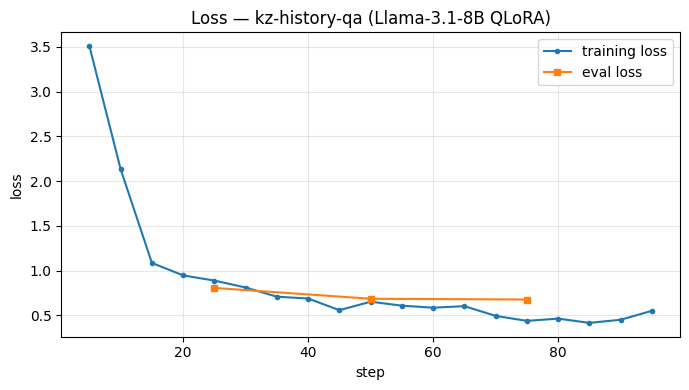

In [17]:
print(f"Effective batch size: {CONFIG['batch_size'] * CONFIG['gradient_accumulation']}")
train_result = trainer.train()
print(f"Training finished. Final training loss: {train_result.training_loss:.4f}")

# ADDED: static loss curve from the training log history (primary "loss decreases" evidence).
# Overlays training loss and eval loss on the same axes (eval rows use the key "eval_loss").
train_logs = [h for h in trainer.state.log_history if "loss" in h]
eval_logs = [h for h in trainer.state.log_history if "eval_loss" in h]
if train_logs:
    plt.figure(figsize=(7, 4))
    plt.plot([h["step"] for h in train_logs], [h["loss"] for h in train_logs],
             marker="o", ms=3, label="training loss")
    if eval_logs:
        plt.plot([h["step"] for h in eval_logs], [h["eval_loss"] for h in eval_logs],
                 marker="s", ms=4, label="eval loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Loss — kz-history-qa (Llama-3.1-8B QLoRA)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("loss_curve.png", dpi=120)
    plt.show()

# 15. SAVE MODEL  (+ optional Hub push — public, per user choice)

In [18]:
trainer.save_model(CONFIG["local_model_dir"])
tokenizer.save_pretrained(CONFIG["local_model_dir"])
print(f"Saved LoRA adapter locally: {CONFIG['local_model_dir']}")

if DO_PUSH:
    model.push_to_hub(MODEL_REPO, private=not CONFIG["hub_public"])
    tokenizer.push_to_hub(MODEL_REPO, private=not CONFIG["hub_public"])
    split.push_to_hub(DATASET_REPO, private=not CONFIG["hub_public"])

    # ADDED (hf-cli skill): overwrite the bare auto-generated README with explicit,
    # informative cards (model + dataset). Russian, no AI-authorship attribution.
    from huggingface_hub import HfApi
    api = HfApi()
    model_card = f"""---
license: llama3.1
language: ru
base_model: {CONFIG['base_model_unsloth']}
library_name: peft
pipeline_tag: question-answering
tags:
- unsloth
- qlora
- kazakhstan-history
---

# {CONFIG['model_name']}

QLoRA-адаптер для `{CONFIG['base_model_unsloth']}`, дообученной отвечать на вопросы
по истории Казахстана (школьный учебник, 11 класс) на русском языке.

## Данные
- Источник: OCR страниц учебника.
- Датасет: {len(sft_data)} пар «вопрос–ответ» — `{DATASET_REPO}`.

## Обучение
- Метод: SFT + QLoRA (Unsloth), 4-bit.
- Эпохи: {CONFIG['num_epochs']}; learning rate: {CONFIG['learning_rate']}; max_length: {CONFIG['max_length']}.
- LoRA: r={CONFIG['lora_r']}, alpha={CONFIG['lora_alpha']}, dropout={CONFIG['lora_dropout']}.

## Использование
Загрузите базовую модель в 4-bit и примените адаптер через PEFT.
"""
    dataset_card = f"""---
language: ru
task_categories:
- question-answering
size_categories:
- n<1K
tags:
- kazakhstan-history
---

# {CONFIG['dataset_name']}

{len(sft_data)} пар «вопрос–ответ» по истории Казахстана (11 класс), полученных по
OCR-тексту учебника. Формат — chat (system / user / assistant); сплит train/test 90/10.
"""
    api.upload_file(path_or_fileobj=model_card.encode("utf-8"),
                    path_in_repo="README.md", repo_id=MODEL_REPO, repo_type="model")
    api.upload_file(path_or_fileobj=dataset_card.encode("utf-8"),
                    path_in_repo="README.md", repo_id=DATASET_REPO, repo_type="dataset")
    # CHANGED: OCR source text is now PUBLIC too — ship it inside the dataset repo.
    api.upload_file(path_or_fileobj=CONFIG["text_path"],
                    path_in_repo="history_text.txt", repo_id=DATASET_REPO, repo_type="dataset")
    print(f"Pushed model:   https://huggingface.co/{MODEL_REPO}")
    print(f"Pushed dataset: https://huggingface.co/datasets/{DATASET_REPO}")
else:
    print("Hub push skipped (set HF_USERNAME + HF_TOKEN to enable).")

Saved LoRA adapter locally: ./kz_history_qa_lora


README.md:   0%|          | 0.00/576 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  557kB /  168MB            

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 6.22kB / 6.22kB            

Pushed model:   https://huggingface.co/timkaiyr/kz-history-qa-llama3.1-8b
Pushed dataset: https://huggingface.co/datasets/timkaiyr/kz-history-qa-dataset


# 16. EVALUATION CONFIGURATION

In [19]:
EVAL_CONFIG = {
    "system_prompt": SYSTEM_PROMPT,
    "max_new_tokens": 256,
    "temperature": 0.7,
    "top_p": 0.9,
    "do_sample": False,      # deterministic -> stable metrics
    "bertscore_lang": "ru",
    "eval_json_path": "evaluation_results.json",
    "eval_csv_path": "evaluation_answers.csv",
}
print("Eval config ready.")

Eval config ready.


# 17. TEST QUESTIONS + REFERENCES

In [20]:
# CHANGED: references come from the held-out eval split (not hardcoded). The spec's
#          questions are always shown qualitatively in Section 19.
# ============================================================
SPEC_QUESTIONS = [
    "Кто такой Махмуд Кашгари?",
    "Какую книгу написал Юсуф Баласагуни?",
    "Что такое Кутадгу билиг?",
    "Кто такой Ходжа Ахмед Яссауи?",
    "Какой вклад внёс аль-Фараби?",   # extra -> ensures >=5 answers
]

# Held-out questions/references for automatic metrics.
eval_questions = [m["messages"][1]["content"] for m in eval_dataset]
reference_answers = [m["messages"][2]["content"] for m in eval_dataset]
print(f"Spec questions: {len(SPEC_QUESTIONS)} | held-out eval: {len(eval_questions)}")

Spec questions: 5 | held-out eval: 29


# 18. PREPARE FINE-TUNED MODEL FOR INFERENCE

In [21]:
FastLanguageModel.for_inference(model)
model.eval()
print("Fine-tuned model ready for inference.")

Fine-tuned model ready for inference.


# 19a. UNIFIED GENERATION FUNCTION + GENERATE FINE-TUNED ANSWERS

In [22]:
def generate_response(model, tokenizer, question,
                      system_prompt=EVAL_CONFIG["system_prompt"],
                      max_new_tokens=EVAL_CONFIG["max_new_tokens"],
                      temperature=EVAL_CONFIG["temperature"],
                      top_p=EVAL_CONFIG["top_p"],
                      do_sample=EVAL_CONFIG["do_sample"]):
    """Generate an answer with the model's chat template (Unsloth or base)."""
    messages = [{"role": "system", "content": system_prompt},
                {"role": "user", "content": question}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]

    kwargs = {"max_new_tokens": max_new_tokens, "do_sample": do_sample,
              "pad_token_id": tokenizer.eos_token_id}
    if do_sample:
        kwargs["temperature"] = temperature
        kwargs["top_p"] = top_p

    with torch.no_grad():
        out = model.generate(**inputs, **kwargs)
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()

print("=== Spec questions (qualitative) ===")
for q in SPEC_QUESTIONS:
    print(f"Q: {q}\nA: {generate_response(model, tokenizer, q)}\n" + "-" * 80)

print("Generating answers for the held-out eval set (for metrics)...")
finetuned_answers = [generate_response(model, tokenizer, q) for q in tqdm(eval_questions)]
print(f"Generated {len(finetuned_answers)} fine-tuned answers.")

=== Spec questions (qualitative) ===
Q: Кто такой Махмуд Кашгари?
A: Махмуд Кашгари — тюркский учёный, путешественник и писатель.
--------------------------------------------------------------------------------
Q: Какую книгу написал Юсуф Баласагуни?
A: «Книга о доблести».
--------------------------------------------------------------------------------
Q: Что такое Кутадгу билиг?
A: Кутадгу билиг — «Знание добродетели».
--------------------------------------------------------------------------------
Q: Кто такой Ходжа Ахмед Яссауи?
A: Ходжа Ахмед Яссауи — выдающийся мыслитель, учёный, поэт, государственный деятель, который внес значительный вклад в развитие общественно-политической мысли, культуры и образования в Казахском ханстве.
--------------------------------------------------------------------------------
Q: Какой вклад внёс аль-Фараби?
A: Аль-Фараби внес значительный вклад в развитие общественно-политической мысли, философии, науки и культуры.
-----------------------------------

100%|██████████| 29/29 [00:58<00:00,  2.00s/it]

Generated 29 fine-tuned answers.


# 20. METRICS (ROUGE / BLEU / BERTScore) — "Fan Score" removed (not applicable).

In [23]:
rouge = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")
bertscore = evaluate.load("bertscore")


def calculate_text_metrics(predictions, references):
    r = rouge.compute(predictions=predictions, references=references)
    b = bleu_metric.compute(predictions=predictions, references=[[x] for x in references])
    bs = bertscore.compute(predictions=predictions, references=references,
                           lang=EVAL_CONFIG["bertscore_lang"])
    return {
        "ROUGE-1": round(r["rouge1"] * 100, 2),
        "ROUGE-2": round(r["rouge2"] * 100, 2),
        "ROUGE-L": round(r["rougeL"] * 100, 2),
        "BLEU": round(b["score"], 2),
        "BERTScore-F1": round(float(np.mean(bs["f1"])) * 100, 2),
    }


finetuned_metrics = calculate_text_metrics(finetuned_answers, reference_answers)
print("Fine-tuned metrics:", finetuned_metrics)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Fine-tuned metrics: {'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0), 'BLEU': 2.47, 'BERTScore-F1': 69.56}


# 21. BASE MODEL EVALUATION (reload base for comparison)

In [24]:
# CHANGED: free the fine-tuned model first (T4 VRAM).
# ============================================================
del model
gc.collect()
torch.cuda.empty_cache()

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=CONFIG["base_model_unsloth"],
    max_seq_length=CONFIG["max_length"],
    load_in_4bit=True,
)
FastLanguageModel.for_inference(base_model)
base_model.eval()

base_answers = [generate_response(base_model, base_tokenizer, q) for q in tqdm(eval_questions)]
base_metrics = calculate_text_metrics(base_answers, reference_answers)
print("Base metrics:", base_metrics)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


100%|██████████| 29/29 [02:29<00:00,  5.17s/it]


Base metrics: {'ROUGE-1': np.float64(0.0), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.0), 'BLEU': 0.52, 'BERTScore-F1': 67.69}


# 22. COMPARE BASE vs FINE-TUNED

In [25]:
rows = []
for k in finetuned_metrics:
    rows.append({"Metric": k, "Base": base_metrics[k],
                 "Fine-tuned": finetuned_metrics[k],
                 "Delta": round(finetuned_metrics[k] - base_metrics[k], 2)})
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
avg_improvement = round(float(np.mean([r["Delta"] for r in rows])), 2)
print(f"\nAverage improvement: {avg_improvement:+.2f}")

      Metric  Base  Fine-tuned  Delta
     ROUGE-1  0.00        0.00   0.00
     ROUGE-2  0.00        0.00   0.00
     ROUGE-L  0.00        0.00   0.00
        BLEU  0.52        2.47   1.95
BERTScore-F1 67.69       69.56   1.87

Average improvement: +0.76


# 23. SAVE EVALUATION RESULTS + CLEAN UP

In [26]:
# ============================================================
pd.DataFrame({
    "question": eval_questions,
    "reference_answer": reference_answers,
    "base_answer": base_answers,
    "finetuned_answer": finetuned_answers,
}).to_csv(EVAL_CONFIG["eval_csv_path"], index=False, encoding="utf-8-sig")

Path(EVAL_CONFIG["eval_json_path"]).write_text(json.dumps({
    "model": MODEL_REPO,
    "dataset": DATASET_REPO,
    "base_model": CONFIG["base_model_unsloth"],
    "num_eval_samples": len(eval_questions),
    "finetuned_metrics": finetuned_metrics,
    "base_metrics": base_metrics,
    "average_improvement": avg_improvement,
    "training": {k: CONFIG[k] for k in ("num_epochs", "learning_rate", "lora_r", "lora_alpha")},
}, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Saved {EVAL_CONFIG['eval_json_path']} and {EVAL_CONFIG['eval_csv_path']}")

del base_model
gc.collect()
torch.cuda.empty_cache()
print("Done. Remember: save the notebook WITH outputs before submitting.")

Saved evaluation_results.json and evaluation_answers.csv
Done. Remember: save the notebook WITH outputs before submitting.
